In [12]:
#Importing pandas,numpy,matplotlib,seaborn,plotly and sqlalchemy libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


from sqlalchemy import create_engine
%matplotlib inline

In [4]:
print("Pandas Version:", pd.__version__)
print("NumPy Version:", np.__version__)
print("Seaborn Version:", sns.__version__)

Pandas Version: 3.0.3
NumPy Version: 2.5.1
Seaborn Version: 0.13.2


In [13]:
#Loading Telco Customer Churn Dataset into pandas dataframe
df = pd.read_csv("../data/Telco Customer Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [14]:
#Checking for missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [17]:
#Checking for duplicate values
df.duplicated().sum()

np.int64(0)

In [18]:
#Removing duplicates
df = df.drop_duplicates()

In [20]:
#Shape of dataset after removing duplicates
df.shape

(7043, 21)

In [21]:
#Checking current data types
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [26]:
# Converting SeniorCitizen from int64 to category
df["SeniorCitizen"] = df["SeniorCitizen"].astype("category")

# Convert all text-based categorical columns
categorical_columns = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
    "Churn"
]

df[categorical_columns] = df[categorical_columns].astype("category")

In [27]:
#to check whether the conversion has done or not
df.dtypes

customerID               str
gender              category
SeniorCitizen       category
Partner             category
Dependents          category
tenure                 int64
PhoneService        category
MultipleLines       category
InternetService     category
OnlineSecurity      category
OnlineBackup        category
DeviceProtection    category
TechSupport         category
StreamingTV         category
StreamingMovies     category
Contract            category
PaperlessBilling    category
PaymentMethod       category
MonthlyCharges       float64
TotalCharges         float64
Churn               category
dtype: object

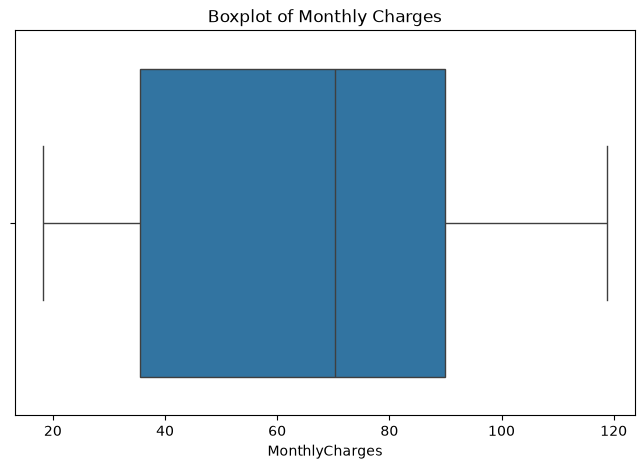

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["MonthlyCharges"])
plt.title("Boxplot of Monthly Charges")
plt.show()

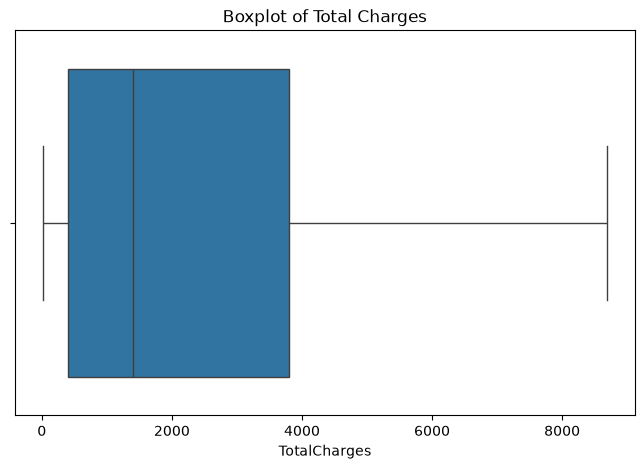

In [29]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["TotalCharges"])
plt.title("Boxplot of Total Charges")
plt.show()

In [34]:
#Handling outliers using IQR method
Q1 = df["MonthlyCharges"].quantile(0.25)
Q3 = df["MonthlyCharges"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 35.5
Q3: 89.85
IQR: 54.349999999999994


In [31]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Lower Limit: -46.02499999999999
Upper Limit: 171.375


In [32]:
outliers = df[(df["MonthlyCharges"] < lower_limit) |
              (df["MonthlyCharges"] > upper_limit)]

print("Number of Outliers:", len(outliers))

Number of Outliers: 0


In [33]:
df = df[(df["MonthlyCharges"] >= lower_limit) &
        (df["MonthlyCharges"] <= upper_limit)]

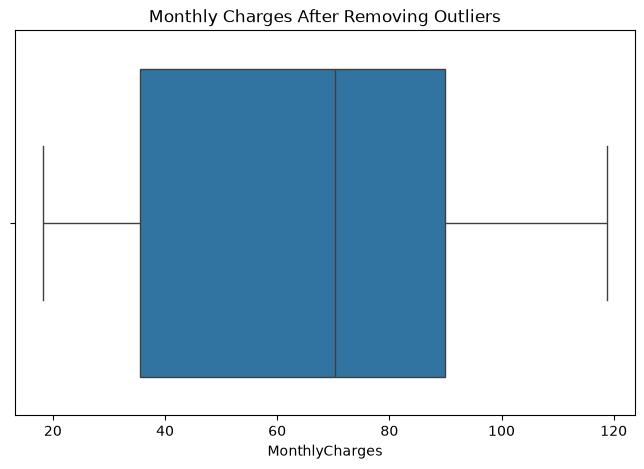

In [35]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["MonthlyCharges"])
plt.title("Monthly Charges After Removing Outliers")
plt.show()

In [36]:
numeric_columns = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [37]:
df.shape

(7032, 21)

In [47]:
import os
save_path = os.path.join("..", "data", "cleaned_dataset.csv")

# Saving the cleaned Dataset
df.to_csv(save_path, index=False)

print(f"Dataset saved to: {os.path.abspath(save_path)}")



Dataset saved to: D:\APEXPLANET_DATA_ANALYTICS\data\cleaned_dataset.csv


In [48]:
df.describe(include='all')
df.info()


<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7032 non-null   str     
 1   gender            7032 non-null   category
 2   SeniorCitizen     7032 non-null   category
 3   Partner           7032 non-null   category
 4   Dependents        7032 non-null   category
 5   tenure            7032 non-null   int64   
 6   PhoneService      7032 non-null   category
 7   MultipleLines     7032 non-null   category
 8   InternetService   7032 non-null   category
 9   OnlineSecurity    7032 non-null   category
 10  OnlineBackup      7032 non-null   category
 11  DeviceProtection  7032 non-null   category
 12  TechSupport       7032 non-null   category
 13  StreamingTV       7032 non-null   category
 14  StreamingMovies   7032 non-null   category
 15  Contract          7032 non-null   category
 16  PaperlessBilling  7032 non-null   catego

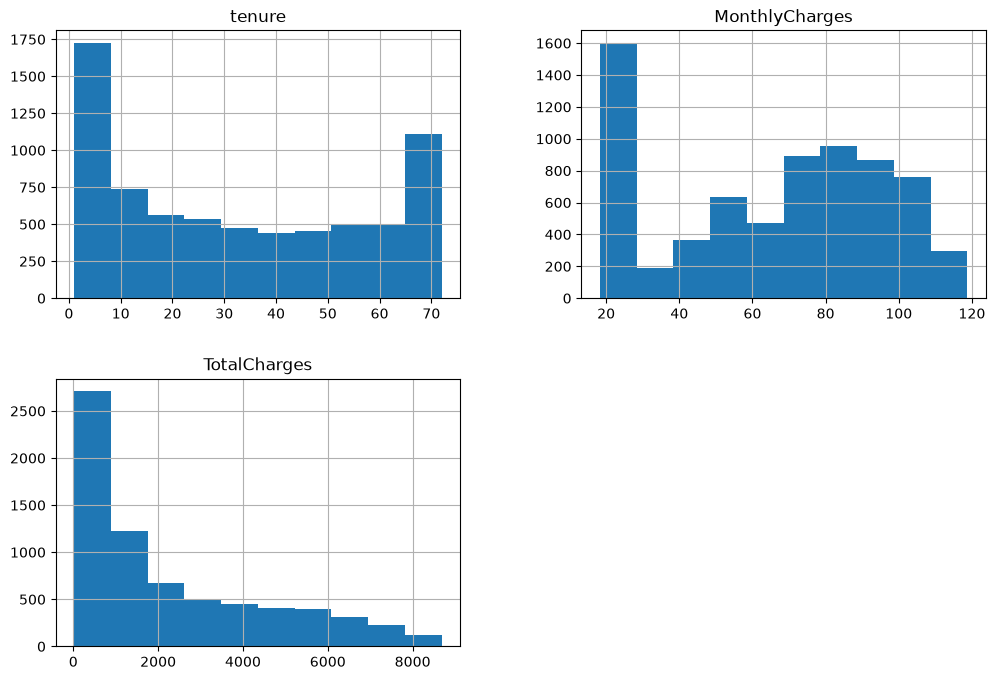

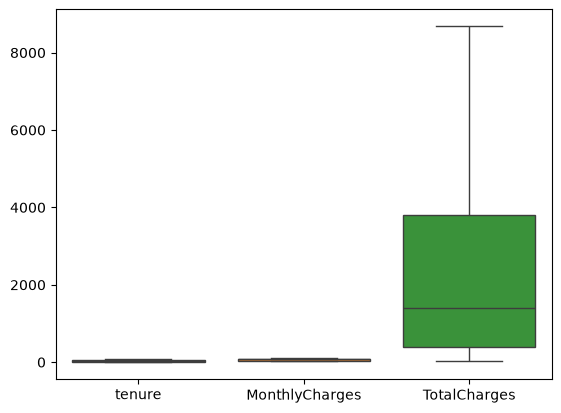

In [50]:
# Visualizations-Histograms
df.hist(figsize=(12, 8))
plt.show()

# Boxplots for outlier detection
sns.boxplot(data=df[numeric_columns])
plt.show()


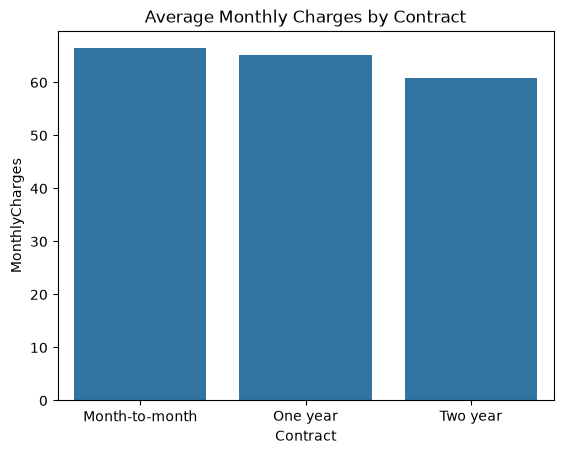

In [51]:
#Bar chart
df_grouped = df.groupby("Contract")["MonthlyCharges"].mean().reset_index()
sns.barplot(x="Contract", y="MonthlyCharges", data=df_grouped)
plt.title("Average Monthly Charges by Contract")
plt.show()


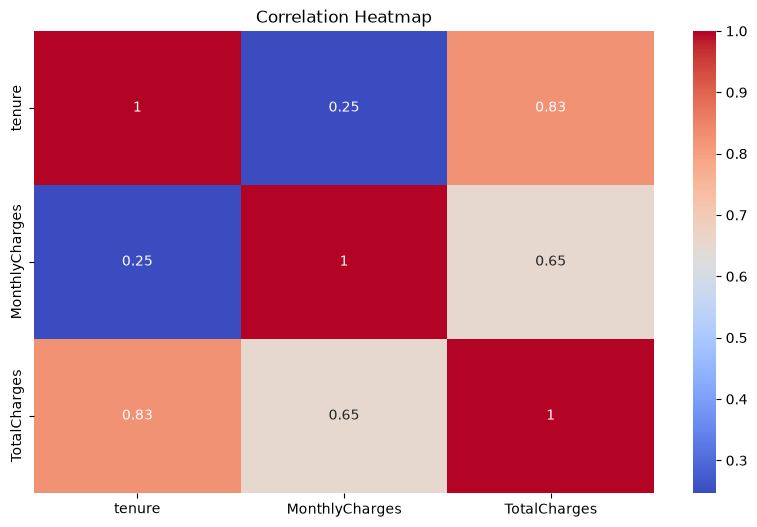

In [53]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


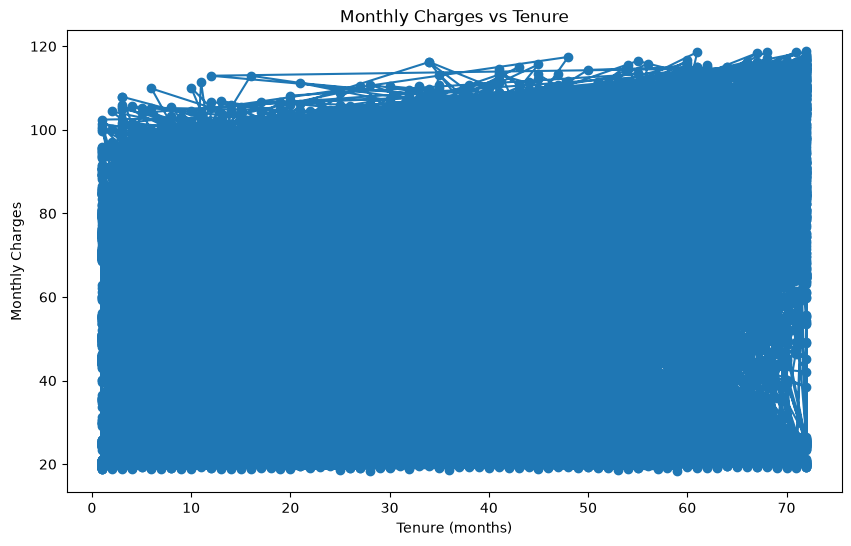

In [56]:
# Linechart
plt.figure(figsize=(10,6))
plt.plot(df["tenure"], df["MonthlyCharges"], marker="o", linestyle="-")
plt.title("Monthly Charges vs Tenure")
plt.xlabel("Tenure (months)")
plt.ylabel("Monthly Charges")
plt.show()


# 5 Key Insights from EDA

1. Customers with longer tenure tend to have lower churn rates.
2. Month-to-month contracts show the highest churn compared to yearly contracts.
3. Higher monthly charges are moderately correlated with churn.
4. Fiber optic internet service customers churn more than DSL customers.
5. Automatic payment methods are associated with lower churn rates.
